# Synthetic Notebook
This notebook is for testing ideas on CF properties.

Below a table of the current status:
| Property | Current Status |
|------------------|------------------|
| Validity | Done |
| Similarity | TODO|
| Sparsity | TODO |
| Plausability | Done |
| Connectedness | TODO |
| Discriminativeness | Done |
| Robustness | Done |
| Stability | Done |
| Actionability | Done |

In [223]:
from copy import deepcopy

from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

from epiuc.uncertainty.classification import MLP_Classifier
from epiuc.uncertainty.wrapper import Ensemble_Classifier, MC_Classifier
import torch

In [224]:

N_CLASSES = 3
X,y = make_classification(n_samples=100,n_informative=2, n_clusters_per_class=1, n_classes=N_CLASSES, random_state=1, n_features=2, n_redundant=0)
X = X.astype(np.float32)
y = y.astype(np.int64)
indices = np.arange(X.shape[0])

X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(X, y, indices, test_size=0.2, random_state=42)

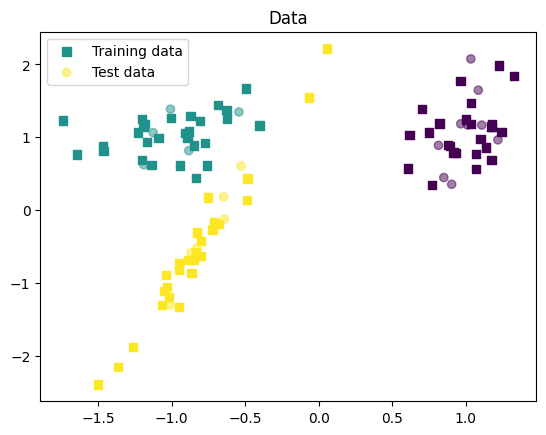

In [225]:
# Visulaize the train and the test data

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker="s", label="Training data")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker="o", label="Test data",alpha=0.5)
plt.title("Data")
plt.legend()
plt.show()

In [226]:


# Define the base model
n_models = 5
base_model = [MLP_Classifier(input_shape=X.shape[1], n_layers=2, num_neurons=100, n_classes=N_CLASSES, dropout_prob=0, batch_norm=False) for _ in range(n_models)]

ensemble_model = Ensemble_Classifier(base_model=base_model, n_models=n_models, random_state=42)

ensemble_model.fit(X_train, y_train, n_epochs=50)


Using MPS Device for training
Using fast routine
Finished Epoch 0 from 50 with 5.548773765563965
Finished Epoch 1 from 50 with 5.318535804748535
Finished Epoch 2 from 50 with 5.099348545074463
Finished Epoch 3 from 50 with 4.890444755554199
Finished Epoch 4 from 50 with 4.690810680389404
Finished Epoch 5 from 50 with 4.500061511993408
Finished Epoch 6 from 50 with 4.317086219787598
Finished Epoch 7 from 50 with 4.14099645614624
Finished Epoch 8 from 50 with 3.971358060836792
Finished Epoch 9 from 50 with 3.807325601577759
Finished Epoch 10 from 50 with 3.648604393005371
Finished Epoch 11 from 50 with 3.4953842163085938
Finished Epoch 12 from 50 with 3.3476295471191406
Finished Epoch 13 from 50 with 3.205124855041504
Finished Epoch 14 from 50 with 3.0676286220550537
Finished Epoch 15 from 50 with 2.935177803039551
Finished Epoch 16 from 50 with 2.807619571685791
Finished Epoch 17 from 50 with 2.684846878051758
Finished Epoch 18 from 50 with 2.566749095916748
Finished Epoch 19 from 50 wi

Ensemble_Classifier()

In [227]:
# calculate the accuracy of the ensemble model
y_pred_proba,_ = ensemble_model.predict(X_test)
y_pred = torch.argmax(y_pred_proba,dim=1)
accuracy = (y_pred == torch.from_numpy(y_test)).sum().item()/len(y_test)
print(f"Accuracy of the ensemble model: {accuracy}")

Accuracy of the ensemble model: 0.95


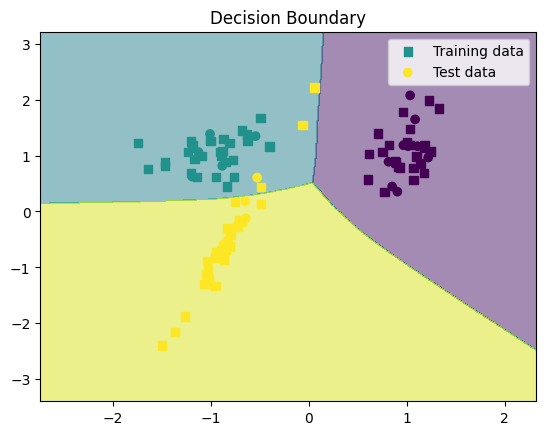

In [228]:
# Visualize the decision boundard through grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
X_grid = np.arange(x_min, x_max, 0.01)
Y_grid = np.arange(y_min, y_max, 0.01)
XX, YY = np.meshgrid(X_grid, Y_grid)
X_grid = np.concatenate([XX.ravel().reshape(-1, 1), YY.ravel().reshape(-1, 1)], axis=1)
X_grid = X_grid.astype(np.float32)
Z,_ = ensemble_model.predict(X_grid)
Z = torch.argmax(Z,dim=1)
Z = Z.reshape(XX.shape)
plt.contourf(XX, YY, Z, alpha=0.5)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker="s", label="Training data")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker="o", label="Test data")
plt.title("Decision Boundary")
plt.legend()
plt.show()

In [229]:

def get_uncertainty_decomposition(model,X, with_grad=False):
    _,uncertanties = model.predict(X,raw_output=True)
    if not with_grad:
        uncertanties = uncertanties.detach().numpy()
    TU,AU,EU = uncertanties[:,0],uncertanties[:,1],uncertanties[:,2]
    return TU,AU,EU

# Visualize the uncertainty decomposition for data
TU_train,AU_train,EU_train = get_uncertainty_decomposition(ensemble_model,X_train)
TU_test,AU_test,EU_test = get_uncertainty_decomposition(ensemble_model,X_test)

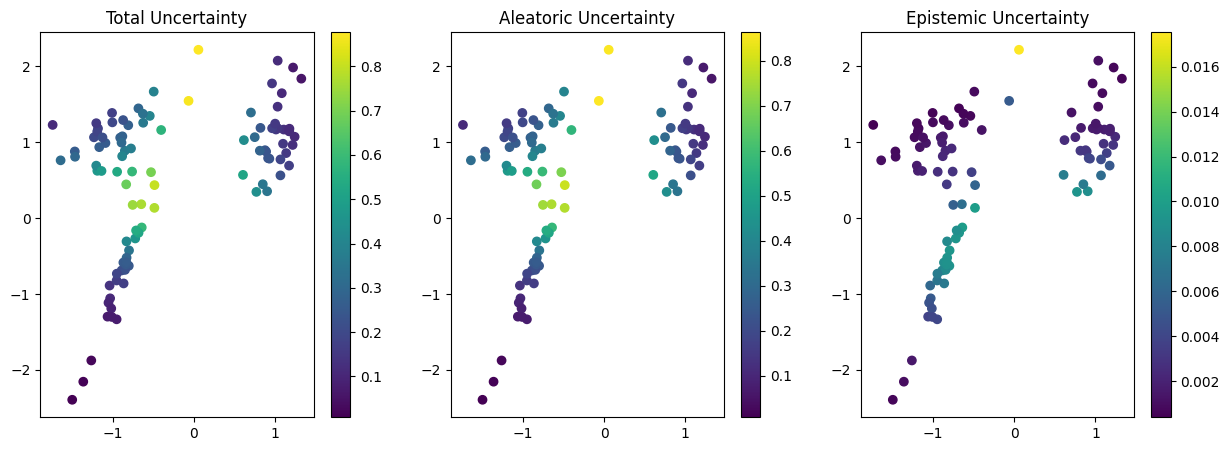

In [230]:
TU_all,AU_all,EU_all = get_uncertainty_decomposition(ensemble_model,X)

fig,ax = plt.subplots(1,3,figsize=(15,5))
image = ax[0].scatter(X[:,0],X[:,1],c=TU_all)
ax[0].set_title("Total Uncertainty")
image2 = ax[1].scatter(X[:,0],X[:,1],c=AU_all)
plt.colorbar(image2)
ax[1].set_title("Aleatoric Uncertainty")
image3 = ax[2].scatter(X[:,0],X[:,1],c=EU_all)
plt.colorbar(image3)
ax[2].set_title("Epistemic Uncertainty")
plt.colorbar(image)
plt.show()

In [231]:
point = np.array([-1,3]).reshape(1,-1)
point = point.astype(np.float32)

TU_point,AU_point,EU_point = get_uncertainty_decomposition(ensemble_model,point)
print(f"Total Uncertainty: {TU_point}")
print(f"Aleatoric Uncertainty: {AU_point}")
print(f"Epistemic Uncertainty: {EU_point}")

Total Uncertainty: [0.07112928]
Aleatoric Uncertainty: [0.070722]
Epistemic Uncertainty: [0.00040729]


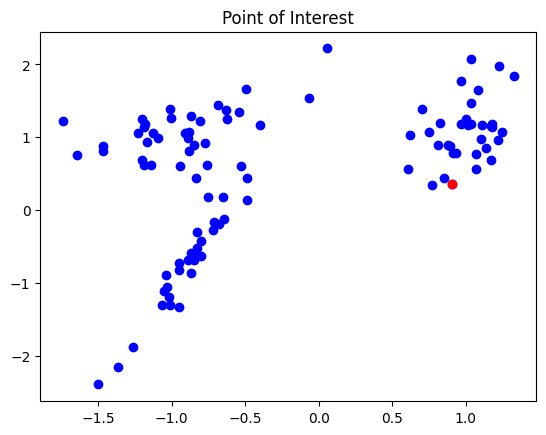

Target Class: 1
Point of Interest: [[0.90394545 0.3541336 ]]
Its Class: [0]


In [232]:
point_of_interest = X[0].reshape(1,-1)
y_point_of_interest = y[0].reshape(1)
plt.title("Point of Interest")
plt.scatter(X[:,0],X[:,1],c="blue")
plt.scatter(point_of_interest[0,0],point_of_interest[0,1],c="red", label="Class 0")
plt.show()
np.random.seed(42)
TARGET_CLASS = np.random.choice([y for y in range(N_CLASSES) if y != y_point_of_interest[0]])
print(f"Target Class: {TARGET_CLASS}")
print(f"Point of Interest: {point_of_interest}")
print(f"Its Class: {y_point_of_interest}")

In [233]:
# adam optimisation routine
def adam_step(point, gradient, betas=(0.999, 0.9), lr=0.1, eps=1e-8, m=0, v=0, t=1):
    m = betas[0]*m + (1-betas[0])*gradient
    v = betas[1]*v + (1-betas[1])*gradient**2
    m_hat = m/(1-betas[0]**t)
    v_hat = v/(1-betas[1]**t)
    point = (point - lr*m_hat/(v_hat**0.5 + eps)).clone().detach().requires_grad_(True)
    return point, (m,v,t+1)

# Validity of Point of Interest

## Simple Approach

In [234]:
def predict_proba(X):
    y_pred_proba,_ = ensemble_model._predict(X)
    return y_pred_proba

cf = deepcopy(point_of_interest).reshape(1,-1)
counter_factual = torch.tensor(cf, requires_grad=True)
tensor_point = torch.tensor(point_of_interest, requires_grad=True)


counter_factual_steps = []
optim = torch.optim.Adam([counter_factual],lr=0.1)

with torch.enable_grad():
    current_proba,_ = ensemble_model._predict(counter_factual)
    m,v,t = 0,0,1
    while current_proba[0,TARGET_CLASS] < 0.8:
        current_proba = -current_proba
        current_proba[0,TARGET_CLASS].backward()
        print("GRADIENT:", counter_factual.grad)
        counter_factual, (m,v,t) = adam_step(counter_factual, counter_factual.grad,lr=0.1,m=m,v=v,t=t)

        #counter_factual = (counter_factual + 0.1*counter_factual.grad).clone().detach().requires_grad_(True)
        with torch.no_grad():
            counter_factual_steps.append(counter_factual.clone())
        print("CF:", counter_factual)
        current_proba,_ = ensemble_model._predict(counter_factual)


GRADIENT: tensor([[0.0723, 0.0249]])
CF: tensor([[0.8039, 0.2541]], requires_grad=True)
GRADIENT: tensor([[0.1016, 0.0252]])
CF: tensor([[0.7062, 0.1542]], requires_grad=True)
GRADIENT: tensor([[0.1320, 0.0159]])
CF: tensor([[0.6107, 0.0548]], requires_grad=True)
GRADIENT: tensor([[ 0.1575, -0.0041]])
CF: tensor([[ 0.5171, -0.0276]], requires_grad=True)
GRADIENT: tensor([[ 0.1593, -0.0290]])
CF: tensor([[ 0.4236, -0.0577]], requires_grad=True)
GRADIENT: tensor([[ 0.1473, -0.0712]])
CF: tensor([[ 0.3295, -0.0409]], requires_grad=True)
GRADIENT: tensor([[ 0.1585, -0.1067]])
CF: tensor([[ 0.2354, -0.0049]], requires_grad=True)
GRADIENT: tensor([[ 0.1711, -0.1608]])
CF: tensor([[0.1416, 0.0399]], requires_grad=True)
GRADIENT: tensor([[ 0.1831, -0.2249]])
CF: tensor([[0.0485, 0.0893]], requires_grad=True)
GRADIENT: tensor([[ 0.2291, -0.3124]])
CF: tensor([[-0.0420,  0.1406]], requires_grad=True)
GRADIENT: tensor([[ 0.2450, -0.3791]])
CF: tensor([[-0.1305,  0.1937]], requires_grad=True)
GRAD

In [235]:
counter_factual_steps = [cf.detach().numpy() for cf in counter_factual_steps]
counter_factual_steps = np.concatenate(counter_factual_steps,axis=0)


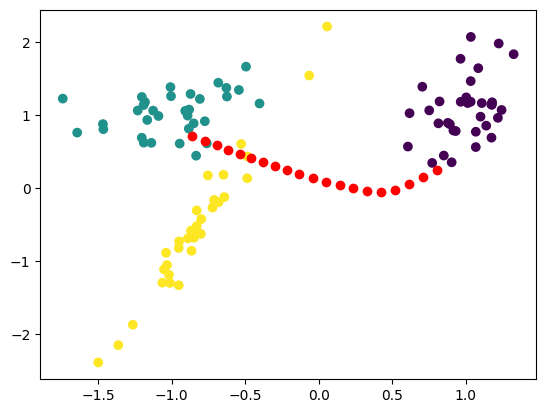

In [236]:

plt.scatter(X[:,0],X[:,1],c=y)
plt.scatter(counter_factual_steps[:,0],counter_factual_steps[:,1],c="red")
plt.show()

## Aleatoric Uncertainty Approach
This is currently restricted to binary classification.

The procedure calculates the AU for the point $x_0$ and then tries to find a counterfactual $x_{cf}$ such that the AU is maximized.
The optimization is done by gradient ascent in the first $T$ steps and then descent in the last $T$ steps.

The optimization is done in two steps:
   - For t=0,...,T-1 compute the AU for the current counterfactual and then maximize it.
   - For t=T,...,2T-1 compute the AU for the current counterfactual and then minimize it.

In [237]:
def get_AU(X):
    TU,AU,EU = get_uncertainty_decomposition(ensemble_model,X,with_grad=True)
    return AU
cf = deepcopy(point_of_interest).reshape(1,-1)
counter_factual = torch.tensor(cf, requires_grad=True)
tensor_point = torch.tensor(point_of_interest, requires_grad=True)


counter_factual_steps = []
T = 20
with torch.enable_grad():
    current_au = get_AU(counter_factual)
    m,v,t = 0,0,1
    for steps in range(1,T+2):
        print("AU:", current_au)
        # First maximize the AU and then minimize it after T steps
        current_au = -(1-steps/T)*current_au


        current_au.backward()
        print("GRADIENT:", counter_factual.grad)
        counter_factual, (m,v,t) = adam_step(counter_factual, counter_factual.grad,lr=0.1,m=m,v=v,t=t)
        print("CF:", counter_factual)
        #counter_factual = (counter_factual + (1 - t/T)*counter_factual.grad).clone().detach().requires_grad_(True)
        with torch.no_grad():
            counter_factual_steps.append(counter_factual.clone())

        current_au = get_AU(counter_factual)


AU: tensor([0.3351], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.5486, 0.2753]])
CF: tensor([[0.8039, 0.2541]], requires_grad=True)
AU: tensor([0.4380], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.6984, 0.3564]])
CF: tensor([[0.7053, 0.1556]], requires_grad=True)
AU: tensor([0.5608], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.7406, 0.3450]])
CF: tensor([[0.6070, 0.0569]], requires_grad=True)
AU: tensor([0.6829], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.6782, 0.2428]])
CF: tensor([[ 0.5083, -0.0424]], requires_grad=True)
AU: tensor([0.7792], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.4428, 0.1007]])
CF: tensor([[ 0.4090, -0.1396]], requires_grad=True)
AU: tensor([0.8205], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.1392, -0.0849]])
CF: tensor([[ 0.3123, -0.2239]], requires_grad=True)
AU: tensor([0.8020], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[-0.1015, -0.2207]])
CF: tensor([[ 0.2234, -0.2842]], requires_grad=True)
AU: tensor([0.7561], grad_fn=<Select

In [238]:
counter_factual_steps = [cf.detach().numpy() for cf in counter_factual_steps]
counter_factual_steps = np.concatenate(counter_factual_steps,axis=0)



In [239]:
# Print some CF
print("Counterfactuals")
print(counter_factual_steps[T//2])
print(counter_factual_steps[T])
print(counter_factual_steps[-1])

Counterfactuals
[-0.03609418 -0.3504112 ]
[-0.37964854 -0.09942234]
[-0.37964854 -0.09942234]


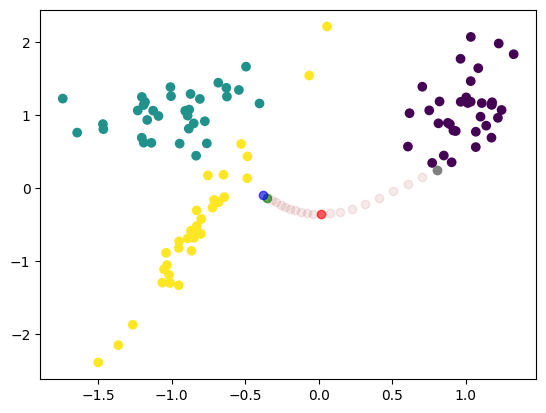

In [240]:

plt.scatter(X[:,0],X[:,1],c=y)
plt.scatter(counter_factual_steps[:,0],counter_factual_steps[:,1],c="brown",alpha=0.1)
plt.scatter(counter_factual_steps[0,0],counter_factual_steps[0,1],c="grey")
plt.scatter(counter_factual_steps[T//2-1,0],counter_factual_steps[T//2-1,1],c="red", alpha=0.6)
plt.scatter(counter_factual_steps[T-1,0],counter_factual_steps[T-1,1],c="green", alpha=0.6)
plt.scatter(counter_factual_steps[-1,0],counter_factual_steps[-1,1],c="blue", alpha=0.6)
plt.show()

In [241]:
get_uncertainty_decomposition(ensemble_model,counter_factual_steps[-1],with_grad=False)

(array([1.1376771], dtype=float32),
 array([0.7209451], dtype=float32),
 array([0.41673195], dtype=float32))

# Actionability
This is achieved by restricting the gradient updates of the features we do not want to change

## Actionable and Valid Counterfactual

In [242]:
# adam optimisation routine
def adam_step_actionable(point, gradient, betas=(0.999, 0.9), lr=0.1, eps=1e-8, m=0, v=0, t=1, restrict_features=None):
    if restrict_features is not None:
        gradient[:,restrict_features] = 0
    print("USED GRADIENT:", gradient)
    m = betas[0]*m + (1-betas[0])*gradient
    v = betas[1]*v + (1-betas[1])*gradient**2
    m_hat = m/(1-betas[0]**t)
    v_hat = v/(1-betas[1]**t)
    point = (point - lr*m_hat/(v_hat**0.5 + eps)).clone().detach().requires_grad_(True)
    return point, (m,v,t+1)

In [243]:
def predict_proba(X):
    y_pred_proba,_ = ensemble_model._predict(X)
    return y_pred_proba

cf = deepcopy(point_of_interest).reshape(1,-1)
counter_factual = torch.tensor(cf, requires_grad=True)
tensor_point = torch.tensor(point_of_interest, requires_grad=True)


counter_factual_steps = []
optim = torch.optim.Adam([counter_factual],lr=0.1)
with torch.enable_grad():
    current_proba,_ = ensemble_model._predict(counter_factual)
    m,v,t = 0,0,1
    while current_proba[0,TARGET_CLASS] < 0.8 and t < T:
        current_proba = -current_proba
        current_proba[0,TARGET_CLASS].backward()
        print("GRADIENT:", counter_factual.grad)
        counter_factual, (m,v,t) = adam_step_actionable(counter_factual, counter_factual.grad,lr=0.1,m=m,v=v,t=t, restrict_features=[1])
        print(t)
        #counter_factual = (counter_factual + 0.1*counter_factual.grad).clone().detach().requires_grad_(True)
        with torch.no_grad():
            counter_factual_steps.append(counter_factual.clone())
        print("CF:", counter_factual)
        current_proba,_ = ensemble_model._predict(counter_factual)


GRADIENT: tensor([[0.0723, 0.0249]])
USED GRADIENT: tensor([[0.0723, 0.0000]])
2
CF: tensor([[0.8039, 0.3541]], requires_grad=True)
GRADIENT: tensor([[0.1007, 0.0279]])
USED GRADIENT: tensor([[0.1007, 0.0000]])
3
CF: tensor([[0.7061, 0.3541]], requires_grad=True)
GRADIENT: tensor([[0.1408, 0.0242]])
USED GRADIENT: tensor([[0.1408, 0.0000]])
4
CF: tensor([[0.6115, 0.3541]], requires_grad=True)
GRADIENT: tensor([[0.1976, 0.0159]])
USED GRADIENT: tensor([[0.1976, 0.0000]])
5
CF: tensor([[0.5212, 0.3541]], requires_grad=True)
GRADIENT: tensor([[ 0.2626, -0.0050]])
USED GRADIENT: tensor([[0.2626, 0.0000]])
6
CF: tensor([[0.4346, 0.3541]], requires_grad=True)
GRADIENT: tensor([[ 0.3207, -0.0304]])
USED GRADIENT: tensor([[0.3207, 0.0000]])
7
CF: tensor([[0.3505, 0.3541]], requires_grad=True)
GRADIENT: tensor([[ 0.3810, -0.0715]])
USED GRADIENT: tensor([[0.3810, 0.0000]])
8
CF: tensor([[0.2683, 0.3541]], requires_grad=True)
GRADIENT: tensor([[ 0.4270, -0.1250]])
USED GRADIENT: tensor([[0.4270,

In [244]:
counter_factual_steps = [cf.detach().numpy() for cf in counter_factual_steps]
counter_factual_steps = np.concatenate(counter_factual_steps,axis=0)


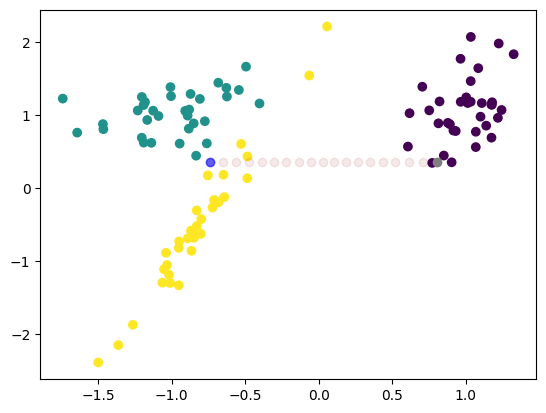

In [245]:

plt.scatter(X[:,0],X[:,1],c=y)
plt.scatter(counter_factual_steps[:,0],counter_factual_steps[:,1],c="brown",alpha=0.1)
plt.scatter(counter_factual_steps[0,0],counter_factual_steps[0,1],c="grey")
plt.scatter(counter_factual_steps[-1,0],counter_factual_steps[-1,1],c="blue", alpha=0.6)
plt.show()

In [246]:
def get_AU(X):
    TU,AU,EU = get_uncertainty_decomposition(ensemble_model,X,with_grad=True)
    return AU
cf = deepcopy(point_of_interest).reshape(1,-1)
counter_factual = torch.tensor(cf, requires_grad=True)
tensor_point = torch.tensor(point_of_interest, requires_grad=True)


counter_factual_steps = []
with torch.enable_grad():
    current_au = get_AU(counter_factual)
    m,v,t = 0,0,1
    for steps in range(1,T+2):
        print("AU:", current_au)
        # First maximize the AU and then minimize it after T steps
        current_au = -(1-steps/T)*current_au


        current_au.backward()
        print("GRADIENT:", counter_factual.grad)
        counter_factual, (m,v,t) = adam_step_actionable(counter_factual, counter_factual.grad,lr=0.1,m=m,v=v,t=t,restrict_features=[1])
        print("CF:", counter_factual)
        #counter_factual = (counter_factual + (1 - t/T)*counter_factual.grad).clone().detach().requires_grad_(True)
        with torch.no_grad():
            counter_factual_steps.append(counter_factual.clone())

        current_au = get_AU(counter_factual)


AU: tensor([0.3351], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.5486, 0.2753]])
USED GRADIENT: tensor([[0.5486, 0.0000]])
CF: tensor([[0.8039, 0.3541]], requires_grad=True)
AU: tensor([0.4004], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.6506, 0.3002]])
USED GRADIENT: tensor([[0.6506, 0.0000]])
CF: tensor([[0.7047, 0.3541]], requires_grad=True)
AU: tensor([0.4815], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.7640, 0.3185]])
USED GRADIENT: tensor([[0.7640, 0.0000]])
CF: tensor([[0.6067, 0.3541]], requires_grad=True)
AU: tensor([0.5772], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.8324, 0.2889]])
USED GRADIENT: tensor([[0.8324, 0.0000]])
CF: tensor([[0.5096, 0.3541]], requires_grad=True)
AU: tensor([0.6800], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.8080, 0.2140]])
USED GRADIENT: tensor([[0.8080, 0.0000]])
CF: tensor([[0.4124, 0.3541]], requires_grad=True)
AU: tensor([0.7803], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.6724, 0.1360]])
USED GRADIENT: tensor([[0

In [247]:
counter_factual_steps = [cf.detach().numpy() for cf in counter_factual_steps]
counter_factual_steps = np.concatenate(counter_factual_steps,axis=0)

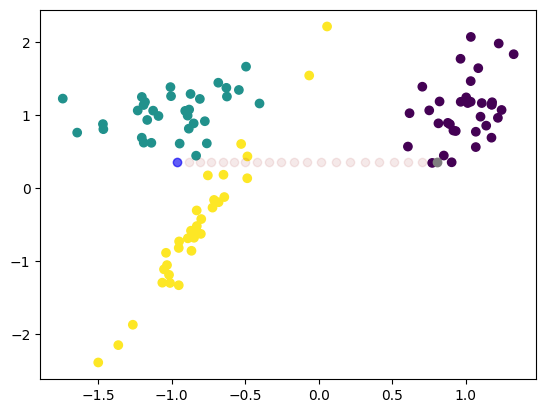

In [248]:

plt.scatter(X[:,0],X[:,1],c=y)
plt.scatter(counter_factual_steps[:,0],counter_factual_steps[:,1],c="brown",alpha=0.1)
plt.scatter(counter_factual_steps[0,0],counter_factual_steps[0,1],c="grey")
plt.scatter(counter_factual_steps[-1,0],counter_factual_steps[-1,1],c="blue", alpha=0.6)
plt.show()

# Stability

We want the CF to land in place, that CF of similiar points as the currently explained would land.

So for this we kinda need to control the gradient in the direction we go.

We can do this by taking a normalized gradient with respect to a ball arount the datapoint.
Then given that our points $\tilde{x} \in B(x,\delta) := \{z \in \mathcal{X} | \quad ||x -z||_2 \leq \delta \}$.
Now given the loss $L(x)$ we want to maximize, we assume without loss of generality that $|\bigtriangledown_x L(x)| \in [0,1]$.

Then it holds that the counter factuals $z^c_t$ for each  $z \in B(x,\delta)$ are within a ball of size $\delta + t\sqrt{n}$, where $n$ is the feature dimension.




In [249]:
from sklearn.neighbors import NearestNeighbors

def knn_point(X_sample ,point,k, point_in_X=True):
    """
    Assumes that point is in X.
    :param X:
    :param point:
    :param k:
    :return:
    """
    knn = NearestNeighbors(n_neighbors=k,algorithm="brute")
    knn.fit(X_sample)
    distances, indices = knn.kneighbors(point)
    return X_sample[indices[0]]

def delta_ball(X_sample, point, delta, norm=2):
    """
    :param X_sample:
    :param point:
    :param delta:
    :return:
    """
    distances = np.linalg.norm(X_sample - point,ord=norm, axis=1)
    return X_sample[distances < delta]

def sample_delta_ball(reference_point, delta, n_points):
    """
    :param point:
    :param delta:
    :param norm:
    :return:
    """
    delta_samples = []
    for _ in range(n_points):
        sample = np.random.randn(*reference_point.shape)
        sample /= np.linalg.norm(sample,ord=2,axis=-1, keepdims=True)
        delta_sample = sample  * delta
        delta_samples.append(delta_sample)
    samples = np.concatenate(delta_samples,axis=0)
    delta_samples = (reference_point + samples).astype(np.float32)
    return torch.tensor(delta_samples, requires_grad=True)

[[0.7715144  0.345716  ]
 [1.0679637  0.5630779 ]
 [0.6066043  0.56998384]]


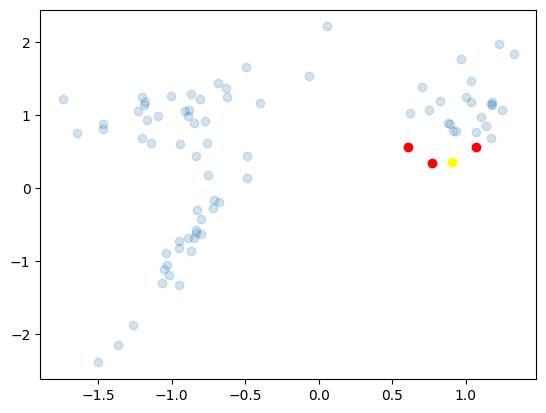

In [250]:

nearest_neighbour_points = knn_point(X_train,point_of_interest,3)
print(nearest_neighbour_points)
plt.scatter(X_train[:,0],X_train[:,1], alpha=0.2)
plt.scatter(nearest_neighbour_points[:,0], nearest_neighbour_points[:,1],c="red")
plt.scatter(point_of_interest[:,0], point_of_interest[:,1],c="yellow")
plt.show()

[[1.138729   0.85729647]
 [0.75148064 1.0670292 ]
 [0.8217832  1.1894778 ]
 [0.915884   0.7903239 ]
 [1.1001848  0.9804274 ]
 [0.8780991  0.8955105 ]
 [1.1735314  1.1480966 ]
 [0.8918914  0.87699467]
 [0.7715144  0.345716  ]
 [1.1745696  0.6921145 ]
 [1.1789943  1.1786728 ]
 [1.1771811  1.1437713 ]
 [1.2432872  1.0725884 ]
 [1.033341   1.18559   ]
 [1.0679637  0.5630779 ]
 [0.9317172  0.78344053]
 [1.0027765  1.245494  ]
 [0.61771417 1.0281748 ]
 [0.6066043  0.56998384]
 [1.0682105  0.77370363]]


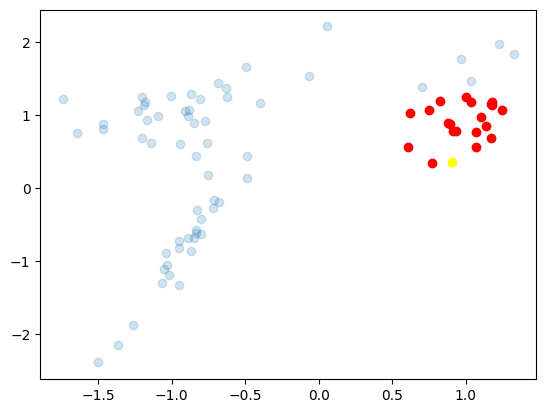

In [251]:
delta_points = delta_ball(X_train,point_of_interest,1)
print(delta_points)
plt.scatter(X_train[:,0],X_train[:,1], alpha=0.2)
plt.scatter(delta_points[:,0], delta_points[:,1],c="red")
plt.scatter(point_of_interest[:,0], point_of_interest[:,1],c="yellow")
plt.show()


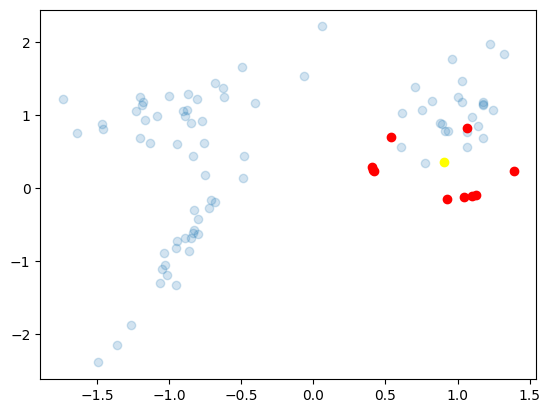

In [252]:
sample_delta_points = sample_delta_ball(point_of_interest,0.5,n_points=10)
plt.scatter(X_train[:,0],X_train[:,1], alpha=0.2)
plt.scatter(sample_delta_points.detach().numpy()[:,0], sample_delta_points.detach().numpy()[:,1],c="red")
plt.scatter(point_of_interest[:,0], point_of_interest[:,1],c="yellow")
plt.show()

In [267]:
cf = deepcopy(point_of_interest).reshape(1,-1)
counter_factual = torch.tensor(cf, requires_grad=True)
tensor_point = torch.tensor(point_of_interest, requires_grad=True)


counter_factual_steps = []
trade_off =  1e-2
delta = 2
with torch.enable_grad():
    counter_factual_ball = sample_delta_ball(counter_factual.clone().detach().numpy(),delta,n_points=20)
    current_proba,_ = ensemble_model._predict(torch.cat((counter_factual,counter_factual_ball),dim=0))
    m,v,t = 0,0,1
    while current_proba[0,TARGET_CLASS] < 0.8:
        print("CURRENT PROBA:", current_proba[0,TARGET_CLASS])
        current_proba = (-current_proba)

        # Compute the gradient for the counterfactual ball
        [
            (current_proba[i,TARGET_CLASS]).backward(retain_graph=True) for i in range(1,counter_factual_ball.shape[0]+1)
        ]
        # Compute the gradient for the counterfactual
        (current_proba[0,TARGET_CLASS]).backward()

        print("GRADIENT:", counter_factual.grad)
        print("GRADIENT BALL:", counter_factual_ball.grad)

        # Normalize counter_factual grad
        min_val = counter_factual_ball.grad.min(dim=0).values
        max_val = counter_factual_ball.grad.max(dim=0).values
        gradient = (counter_factual.grad - min_val) / (max_val - min_val)
        mask = 1 - 2*(torch.sign(gradient) - torch.sign(counter_factual.grad))
        gradient = mask*gradient
        #gradient = counter_factual.grad
        print("Normalized gradient: ", gradient)

        # normalize counter factual
        normalized_cf = (counter_factual - min_val) / (max_val - min_val)
        #normalized_cf = counter_factual
        print("Normalized CF: ", normalized_cf)
        normalized_cf, (m,v,t) = adam_step(normalized_cf, gradient,lr=0.1,m=m,v=v,t=t)

        # Put counter_factual back to normal
        counter_factual = (normalized_cf * (max_val - min_val) + min_val).clone().detach().requires_grad_(True)
        print("NEW CF: ", counter_factual)
        #counter_factual = normalized_cf

        with torch.no_grad():
            counter_factual_steps.append(counter_factual.clone())

        counter_factual_ball = sample_delta_ball(counter_factual.clone().detach().numpy(),delta,n_points=20)
        current_proba,_ = ensemble_model._predict(torch.cat((counter_factual,counter_factual_ball),dim=0))


final_cf_of_point_of_interest = counter_factual.clone().detach().numpy()

CURRENT PROBA: tensor(0.0291, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0723, 0.0249]])
GRADIENT BALL: tensor([[ 4.5225e-03,  5.8935e-04],
        [ 4.7250e-03, -1.4366e-02],
        [-1.1656e-02, -3.8910e-02],
        [ 4.2185e-02, -7.1464e-04],
        [ 5.1163e-04,  2.9408e-04],
        [ 9.2312e-02, -8.4986e-01],
        [ 7.4820e-03, -2.4821e-03],
        [ 5.7741e-02, -5.8591e-01],
        [ 4.7644e-04,  2.7681e-04],
        [ 2.9653e-01, -4.9337e-02],
        [ 4.9306e-03,  4.4831e-04],
        [-1.1418e-02, -3.7718e-02],
        [ 3.8424e-03, -1.5505e-02],
        [ 8.0387e-04,  4.2925e-04],
        [ 4.6728e-04,  2.7268e-04],
        [ 6.3908e-01, -5.4455e-02],
        [ 2.9500e-03, -1.6553e-02],
        [-7.2815e-03, -2.4467e-02],
        [ 6.6493e-03,  5.2081e-04],
        [ 1.2927e-02,  3.3817e-04]])
Normalized gradient:  tensor([[0.1290, 1.0286]])
Normalized CF:  tensor([[1.4070, 1.4157]], grad_fn=<DivBackward0>)
NEW CF:  tensor([[0.8389, 0.2691]], requires_grad=True

In [268]:
counter_factual_steps = [cf.detach().numpy() for cf in counter_factual_steps]
counter_factual_steps = np.concatenate(counter_factual_steps,axis=0)


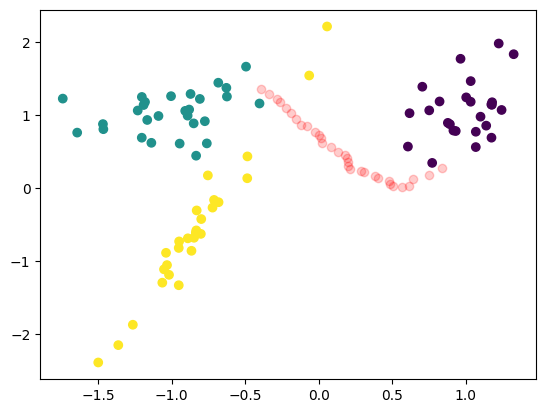

In [269]:

plt.scatter(X_train[:,0],X_train[:,1],c=y_train)
plt.scatter(counter_factual_steps[:,0],counter_factual_steps[:,1],c="red",alpha=.2)
plt.show()

CURRENT PROBA: tensor(0.0413, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1137, 0.0270]])
GRADIENT BALL: tensor([[ 6.3690e-03, -1.2632e-02],
        [ 5.5203e-02, -1.3739e-03],
        [ 4.9320e-01, -4.8314e-02],
        [ 2.6504e-03,  5.8497e-04],
        [ 5.9585e-02, -9.3049e-01],
        [ 8.7206e-03, -3.9338e-03],
        [ 1.7862e-03,  7.7995e-04],
        [ 7.6223e-04,  4.4216e-04],
        [ 6.3483e-03,  8.2314e-05],
        [ 6.1739e-03, -1.2979e-02],
        [ 6.5770e-04,  3.8695e-04],
        [-7.6147e-03, -2.2605e-02],
        [ 6.2131e-02, -2.2115e-01],
        [ 3.1930e-02, -1.1383e-04],
        [ 4.7008e-03,  8.6244e-04],
        [ 1.3294e-03,  5.2166e-04],
        [ 2.3493e-01, -4.1269e-02],
        [ 9.3280e-03, -1.9509e-01],
        [ 5.5238e-02, -8.9126e-01],
        [-1.4938e-02, -4.8360e-02]])
Normalized gradient:  tensor([[0.2532, 1.0281]])
Normalized CF:  tensor([[1.5477, 1.3703]], grad_fn=<DivBackward0>)
NEW CF:  tensor([[0.7350, 0.4224]], requires_grad=True

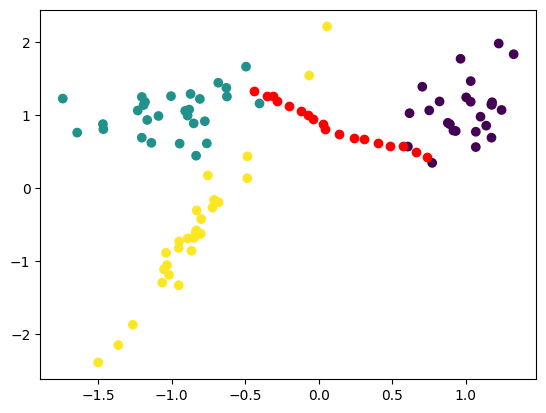

CURRENT PROBA: tensor(0.0163, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0382, 0.0161]])
GRADIENT BALL: tensor([[ 4.1324e-04,  2.3189e-04],
        [ 2.5600e-04,  1.5351e-04],
        [-1.3214e-02, -4.9677e-02],
        [ 8.5593e-03, -1.7256e-02],
        [ 1.0717e+00, -6.1857e-02],
        [ 1.7074e-01, -9.1839e-01],
        [ 1.6556e-03,  5.6117e-04],
        [ 4.6410e-03,  6.1982e-04],
        [ 4.7470e-04,  2.6534e-04],
        [ 2.2165e-01, -4.7620e-02],
        [ 2.3371e-03,  2.9220e-04],
        [-2.5917e-02, -1.1451e-01],
        [ 2.5273e-03,  2.7107e-04],
        [ 3.8877e-04,  1.9405e-04],
        [ 1.2193e-01, -8.8936e-01],
        [ 3.3898e-01, -4.7381e-02],
        [ 3.3325e-04,  1.9607e-04],
        [ 5.2878e-04,  2.9105e-04],
        [ 2.3558e-03,  5.7036e-04],
        [ 1.7387e-03,  5.0869e-04]])
Normalized gradient:  tensor([[0.0584, 1.0168]])
Normalized CF:  tensor([[0.9966, 1.6120]], grad_fn=<DivBackward0>)
NEW CF:  tensor([[0.9802, 0.6311]], requires_grad=True

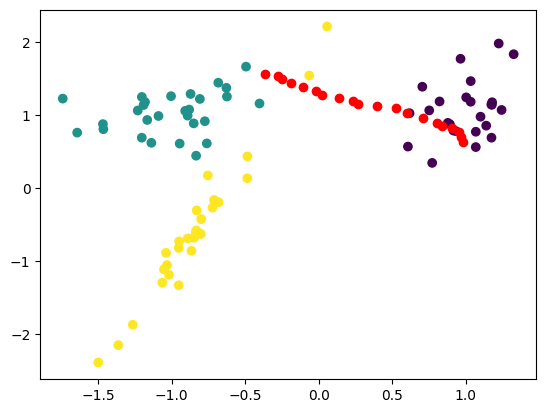

CURRENT PROBA: tensor(0.0617, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.2209, 0.0257]])
GRADIENT BALL: tensor([[ 1.0222e-03,  5.9484e-04],
        [ 1.2017e-02, -3.3116e-03],
        [ 6.8119e-02, -5.2671e-01],
        [ 4.2273e-01, -3.9609e-02],
        [ 9.3873e-01, -6.2427e-02],
        [-1.1172e-02, -3.4045e-02],
        [ 1.9442e-01, -8.9415e-03],
        [-1.5225e-02, -4.6900e-02],
        [ 1.4408e-02, -7.4815e-03],
        [ 6.1299e-03,  1.4784e-03],
        [ 7.5157e-04,  4.4399e-04],
        [ 6.9982e-02, -5.4363e-01],
        [ 2.3068e-03,  1.0422e-03],
        [-9.3027e-03, -3.1504e-02],
        [ 3.3351e-03,  1.2307e-03],
        [ 6.7386e-04,  4.1187e-04],
        [ 1.1114e-03,  6.1283e-04],
        [ 1.0248e-01, -2.4327e-02],
        [ 1.0927e-03,  4.4113e-04],
        [ 2.7195e-01, -3.0630e-02]])
Normalized gradient:  tensor([[0.2475, 1.0445]])
Normalized CF:  tensor([[0.6518, 2.0429]], grad_fn=<DivBackward0>)
NEW CF:  tensor([[0.5280, 0.6035]], requires_grad=True

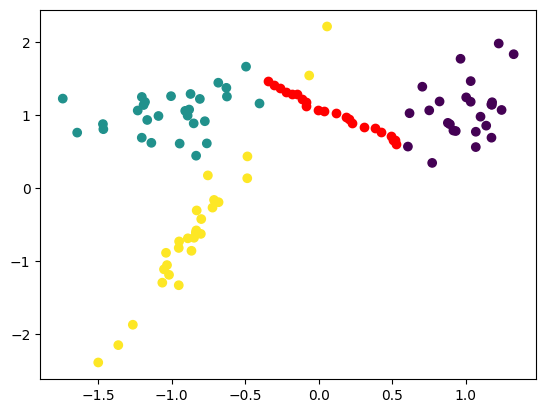

In [270]:

cf = deepcopy(point_of_interest).reshape(1,-1)
counter_factual = torch.tensor(cf, requires_grad=True)
tensor_point = torch.tensor(point_of_interest, requires_grad=True)


final_cf = []
for point in knn_point(X_train,point_of_interest,3):
    cf = deepcopy(point).reshape(1,-1)

    counter_factual_steps = []

    counter_factual = torch.tensor(cf, requires_grad=True)
    counter_factual_ball = sample_delta_ball(counter_factual.clone().detach().numpy(),delta,n_points=20)

    current_proba,_ = ensemble_model._predict(torch.cat((counter_factual,counter_factual_ball),dim=0))
    while current_proba[0,TARGET_CLASS] < 0.8:
            print("CURRENT PROBA:", current_proba[0,TARGET_CLASS])
            current_proba = (-current_proba)

            # Compute the gradient for the counterfactual ball
            [
                (current_proba[i,TARGET_CLASS]).backward(retain_graph=True) for i in range(1,counter_factual_ball.shape[0]+1)
            ]
            # Compute the gradient for the counterfactual
            (current_proba[0,TARGET_CLASS]).backward()

            print("GRADIENT:", counter_factual.grad)
            print("GRADIENT BALL:", counter_factual_ball.grad)

            # Normalize counter_factual grad
            min_val = counter_factual_ball.grad.min(dim=0).values
            max_val = counter_factual_ball.grad.max(dim=0).values
            gradient = (counter_factual.grad - min_val) / (max_val - min_val)
            mask = 1 - 2*(torch.sign(gradient) - torch.sign(counter_factual.grad))
            gradient = mask*gradient
            #gradient = counter_factual.grad
            print("Normalized gradient: ", gradient)

            # normalize counter factual
            normalized_cf = (counter_factual - min_val) / (max_val - min_val)
            #normalized_cf = counter_factual
            print("Normalized CF: ", normalized_cf)
            normalized_cf, (m,v,t) = adam_step(normalized_cf, gradient,lr=0.1,m=m,v=v,t=t)

            # Put counter_factual back to normal
            counter_factual = (normalized_cf * (max_val - min_val) + min_val).clone().detach().requires_grad_(True)
            print("NEW CF: ", counter_factual)
            #counter_factual = normalized_cf

            counter_factual_steps.append(counter_factual.clone().detach())

            counter_factual_ball = sample_delta_ball(counter_factual.clone().detach().numpy(),delta,n_points=20)
            current_proba,_ = ensemble_model._predict(torch.cat((counter_factual,counter_factual_ball),dim=0))

    counter_factual_steps = [cf.detach().numpy() for cf in counter_factual_steps]
    counter_factual_steps = np.concatenate(counter_factual_steps,axis=0)

    plt.scatter(X_train[:,0],X_train[:,1],c=y_train)
    plt.scatter(counter_factual_steps[:,0],counter_factual_steps[:,1],c="red")
    plt.show()

    final_cf.append(counter_factual.detach().clone().numpy())


In [271]:
final_cf, final_cf_of_point_of_interest
# Compute the norms
for cf in final_cf:
    print(np.linalg.norm(cf.flatten() - final_cf_of_point_of_interest.flatten(), ord=2))

0.05594604
0.21221517
0.1217036


CURRENT PROBA: tensor(0.0194, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0556, 0.0164]])
GRADIENT BALL: tensor([[0.0621, 0.0206],
        [0.1061, 0.0259],
        [0.0201, 0.0097],
        [0.0233, 0.0061],
        [0.3133, 0.0127],
        [0.0589, 0.0199],
        [0.0218, 0.0101],
        [0.0699, 0.0217],
        [0.0130, 0.0064],
        [0.0234, 0.0061],
        [0.0259, 0.0115],
        [0.0938, 0.0031],
        [0.1178, 0.0033],
        [0.0384, 0.0151],
        [0.0149, 0.0074],
        [0.0192, 0.0094],
        [0.0118, 0.0058],
        [0.0935, 0.0256],
        [0.0215, 0.0057],
        [0.0634, 0.0209]])
Normalized gradient:  tensor([[0.1453, 0.5849]])
Normalized CF:  tensor([[ 2.9984, 34.4722]], grad_fn=<DivBackward0>)
NEW CF:  tensor([[0.8813, 0.7915]], requires_grad=True)
CURRENT PROBA: tensor(0.0215, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0656, 0.0171]])
GRADIENT BALL: tensor([[ 0.0127,  0.0064],
        [ 0.0152,  0.0074],
        [ 0.5247, -0.0091],
   

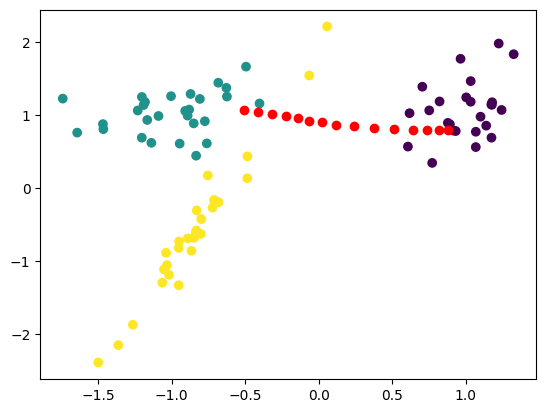

CURRENT PROBA: tensor(0.0413, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1137, 0.0270]])
GRADIENT BALL: tensor([[ 0.4991, -0.0455],
        [ 0.0922,  0.0040],
        [ 0.0258,  0.0116],
        [ 0.0258,  0.0116],
        [ 0.0271,  0.0116],
        [ 0.0498,  0.0134],
        [ 0.4472,  0.0084],
        [ 0.1184, -0.0138],
        [ 0.0272,  0.0124],
        [ 0.4947, -0.0644],
        [ 0.4882,  0.0006],
        [ 0.1429,  0.0148],
        [ 0.0935,  0.0026],
        [ 0.1820, -0.0750],
        [ 0.4950, -0.0617],
        [ 0.0325,  0.0121],
        [ 0.4362, -0.1208],
        [ 0.4910, -0.0600],
        [ 0.4406,  0.0091],
        [ 0.1550, -0.0634]])
Normalized gradient:  tensor([[0.1859, 1.0902]])
Normalized CF:  tensor([[1.5756, 3.4413]], grad_fn=<DivBackward0>)
NEW CF:  tensor([[0.7177, 0.3522]], requires_grad=True)
CURRENT PROBA: tensor(0.0479, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1357, 0.0243]])
GRADIENT BALL: tensor([[ 0.5664, -0.0619],
        [ 0.2331, -0.

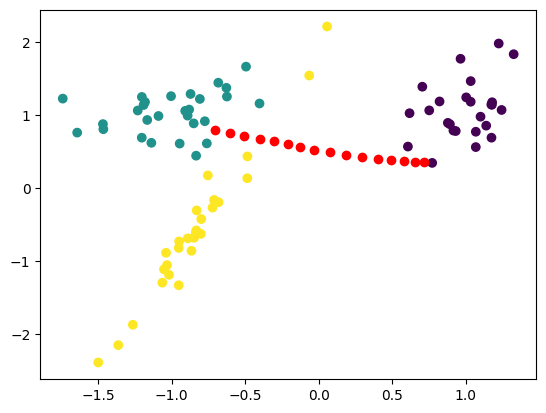

CURRENT PROBA: tensor(0.0112, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0254, 0.0115]])
GRADIENT BALL: tensor([[0.0227, 0.0096],
        [0.0445, 0.0076],
        [0.1156, 0.0279],
        [0.0188, 0.0080],
        [0.0078, 0.0040],
        [0.1679, 0.0191],
        [0.0272, 0.0108],
        [0.0084, 0.0042],
        [0.1347, 0.0137],
        [0.0195, 0.0084],
        [0.0600, 0.0080],
        [0.0859, 0.0101],
        [0.1004, 0.0280],
        [0.0814, 0.0237],
        [0.0351, 0.0129],
        [0.0095, 0.0050],
        [0.0072, 0.0038],
        [0.0183, 0.0079],
        [0.1134, 0.0281],
        [0.0414, 0.0144]])
Normalized gradient:  tensor([[0.1130, 0.3181]])
Normalized CF:  tensor([[ 7.2661, 28.3979]], grad_fn=<DivBackward0>)
NEW CF:  tensor([[1.1530, 0.6935]], requires_grad=True)
CURRENT PROBA: tensor(0.0118, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0270, 0.0121]])
GRADIENT BALL: tensor([[0.0136, 0.0065],
        [0.0141, 0.0067],
        [0.0112, 0.0051],
        [

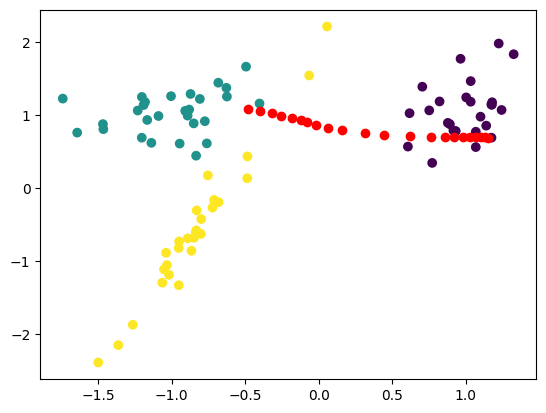

CURRENT PROBA: tensor(0.0163, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0382, 0.0161]])
GRADIENT BALL: tensor([[0.0196, 0.0084],
        [0.1245, 0.0201],
        [0.1146, 0.0209],
        [0.0722, 0.0186],
        [0.2462, 0.0210],
        [0.1792, 0.0146],
        [0.0182, 0.0077],
        [0.0106, 0.0054],
        [0.0874, 0.0207],
        [0.1341, 0.0140],
        [0.2330, 0.0163],
        [0.0228, 0.0090],
        [0.0135, 0.0067],
        [0.0505, 0.0150],
        [0.2207, 0.0155],
        [0.0126, 0.0062],
        [0.0192, 0.0083],
        [0.0140, 0.0065],
        [0.0351, 0.0117],
        [0.0487, 0.0150]])
Normalized gradient:  tensor([[0.1171, 0.6867]])
Normalized CF:  tensor([[ 4.4875, 35.8153]], grad_fn=<DivBackward0>)
NEW CF:  tensor([[1.0452, 0.5639]], requires_grad=True)
CURRENT PROBA: tensor(0.0172, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0404, 0.0163]])
GRADIENT BALL: tensor([[0.0472, 0.0142],
        [0.0784, 0.0190],
        [0.0618, 0.0162],
        [

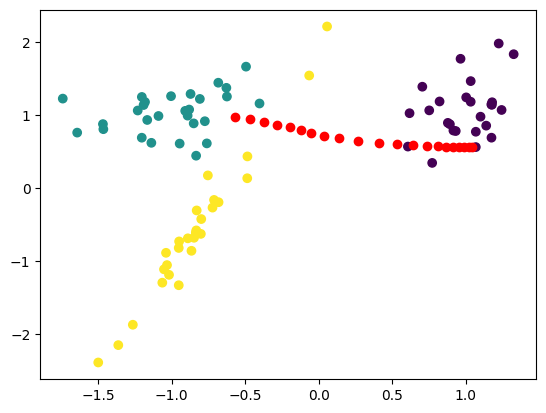

CURRENT PROBA: tensor(0.0187, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0517, 0.0161]])
GRADIENT BALL: tensor([[ 0.0510,  0.0180],
        [ 0.3465,  0.0013],
        [ 0.1522,  0.0031],
        [ 0.0167,  0.0083],
        [ 0.4189, -0.0012],
        [ 0.0916,  0.0025],
        [ 0.0117,  0.0056],
        [ 0.0381,  0.0149],
        [ 0.0835,  0.0233],
        [ 0.0475,  0.0176],
        [ 0.0152,  0.0060],
        [ 0.1609,  0.0033],
        [ 0.0145,  0.0059],
        [ 0.0116,  0.0056],
        [ 0.0191,  0.0092],
        [ 0.2063,  0.0041],
        [ 0.0478,  0.0040],
        [ 0.0131,  0.0056],
        [ 0.4169, -0.0012],
        [ 0.4101,  0.0009]])
Normalized gradient:  tensor([[0.0986, 0.7087]])
Normalized CF:  tensor([[ 2.2589, 32.0276]], grad_fn=<DivBackward0>)
NEW CF:  tensor([[0.8851, 0.7847]], requires_grad=True)
CURRENT PROBA: tensor(0.0214, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0642, 0.0172]])
GRADIENT BALL: tensor([[ 0.2806,  0.0076],
        [ 0.2736,  

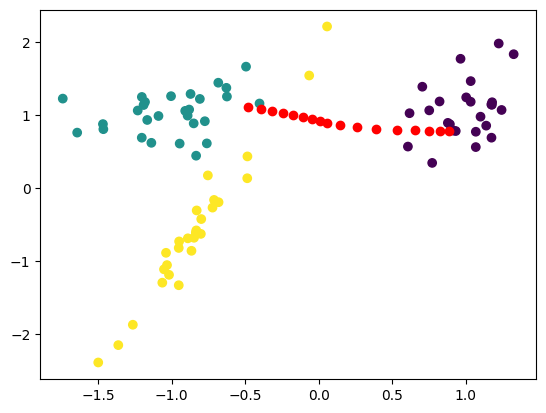

CURRENT PROBA: tensor(0.0617, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.2209, 0.0257]])
GRADIENT BALL: tensor([[ 7.9870e-01, -1.4191e-01],
        [ 2.0509e-01,  2.9459e-03],
        [ 3.2671e-02,  1.3093e-02],
        [ 3.4001e-02,  1.4873e-02],
        [ 6.6032e-01, -2.2433e-01],
        [ 4.1307e-01, -3.0915e-03],
        [ 3.0632e-01,  1.9165e-03],
        [ 3.1993e-02,  1.3944e-02],
        [ 3.6306e-02,  1.2724e-02],
        [ 3.8253e-02,  1.5589e-02],
        [ 7.4178e-01, -1.6202e-02],
        [ 6.8251e-02,  2.0713e-02],
        [ 3.2454e-02,  1.3412e-02],
        [ 7.4229e-01, -1.6252e-02],
        [ 2.9552e-01, -1.2497e-01],
        [ 6.8326e-02,  2.0728e-02],
        [ 1.5496e-01,  4.6182e-04],
        [ 2.6753e-01, -9.5686e-02],
        [ 2.5300e-01,  1.1145e-03],
        [ 3.5537e-02,  1.5089e-02]])
Normalized gradient:  tensor([[0.2464, 1.0204]])
Normalized CF:  tensor([[0.7495, 3.2413]], grad_fn=<DivBackward0>)
NEW CF:  tensor([[0.5346, 0.5810]], requires_grad=True

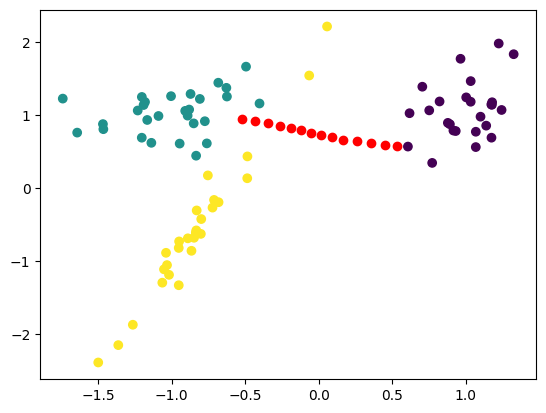

CURRENT PROBA: tensor(0.0133, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0323, 0.0130]])
GRADIENT BALL: tensor([[0.0444, 0.0041],
        [0.0224, 0.0058],
        [0.1383, 0.0288],
        [0.0280, 0.0114],
        [0.0100, 0.0051],
        [0.0317, 0.0129],
        [0.0322, 0.0133],
        [0.0631, 0.0042],
        [0.0438, 0.0165],
        [0.0217, 0.0057],
        [0.0200, 0.0089],
        [0.0861, 0.0255],
        [0.2182, 0.0263],
        [0.0116, 0.0059],
        [0.0531, 0.0188],
        [0.0456, 0.0164],
        [0.0937, 0.0273],
        [0.2212, 0.0247],
        [0.0474, 0.0166],
        [0.2391, 0.0237]])
Normalized gradient:  tensor([[0.0972, 0.3603]])
Normalized CF:  tensor([[ 4.6199, 31.1609]], grad_fn=<DivBackward0>)
NEW CF:  tensor([[1.0447, 0.7749]], requires_grad=True)
CURRENT PROBA: tensor(0.0140, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0344, 0.0135]])
GRADIENT BALL: tensor([[0.0247, 0.0104],
        [0.0150, 0.0055],
        [0.1053, 0.0280],
        [

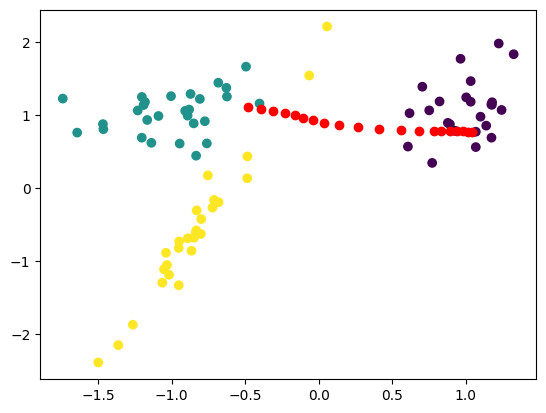

In [276]:

cf = deepcopy(point_of_interest).reshape(1,-1)
counter_factual = torch.tensor(cf, requires_grad=True)
tensor_point = torch.tensor(point_of_interest, requires_grad=True)


final_cf = []
for point in delta_ball(X_train,point_of_interest,delta,norm=2):
    cf = deepcopy(point).reshape(1,-1)

    counter_factual_steps = []

    counter_factual = torch.tensor(cf, requires_grad=True)
    counter_factual_ball = sample_delta_ball(counter_factual.clone().detach().numpy(),delta,n_points=20)

    current_proba,_ = ensemble_model._predict(torch.cat((counter_factual,counter_factual_ball),dim=0))
    while current_proba[0,TARGET_CLASS] < 0.8:
            print("CURRENT PROBA:", current_proba[0,TARGET_CLASS])
            current_proba = (-current_proba)

            # Compute the gradient for the counterfactual ball
            [
                (current_proba[i,TARGET_CLASS]).backward(retain_graph=True) for i in range(1,counter_factual_ball.shape[0]+1)
            ]
            # Compute the gradient for the counterfactual
            (current_proba[0,TARGET_CLASS]).backward()

            print("GRADIENT:", counter_factual.grad)
            print("GRADIENT BALL:", counter_factual_ball.grad)

            # Normalize counter_factual grad
            min_val = counter_factual_ball.grad.min(dim=0).values
            max_val = counter_factual_ball.grad.max(dim=0).values
            gradient = (counter_factual.grad - min_val) / (max_val - min_val)
            mask = 1 - 2*(torch.sign(gradient) - torch.sign(counter_factual.grad))
            gradient = mask*gradient
            #gradient = counter_factual.grad
            print("Normalized gradient: ", gradient)

            # normalize counter factual
            normalized_cf = (counter_factual - min_val) / (max_val - min_val)
            #normalized_cf = counter_factual
            print("Normalized CF: ", normalized_cf)
            normalized_cf, (m,v,t) = adam_step(normalized_cf, gradient,lr=0.1,m=m,v=v,t=t)

            # Put counter_factual back to normal
            counter_factual = (normalized_cf * (max_val - min_val) + min_val).clone().detach().requires_grad_(True)
            print("NEW CF: ", counter_factual)
            #counter_factual = normalized_cf

            counter_factual_steps.append(counter_factual.clone().detach())

            counter_factual_ball = sample_delta_ball(counter_factual.clone().detach().numpy(),delta,n_points=20)
            current_proba,_ = ensemble_model._predict(torch.cat((counter_factual,counter_factual_ball),dim=0))

    counter_factual_steps = [cf.detach().numpy() for cf in counter_factual_steps]
    counter_factual_steps = np.concatenate(counter_factual_steps,axis=0)

    plt.scatter(X_train[:,0],X_train[:,1],c=y_train)
    plt.scatter(counter_factual_steps[:,0],counter_factual_steps[:,1],c="red")
    plt.show()

    final_cf.append(counter_factual.detach().clone().numpy())


In [277]:
final_cf, final_cf_of_point_of_interest
# Compute the norms
for cf in final_cf:
    print(np.linalg.norm(cf.flatten() - final_cf_of_point_of_interest.flatten(), ord=2))

0.305599
0.63990396
0.2885526
0.4220232
0.26523447
0.42539802
0.26452228


 without considering the ball around the cf

CURRENT PROBA: tensor(0.0413, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.6715, 0.2457]], requires_grad=True)
CURRENT PROBA: tensor(0.0571, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.5737, 0.1465]], requires_grad=True)
CURRENT PROBA: tensor(0.0750, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.4769, 0.0646]], requires_grad=True)
CURRENT PROBA: tensor(0.0921, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.3805, 0.0500]], requires_grad=True)
CURRENT PROBA: tensor(0.1103, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.2842, 0.0792]], requires_grad=True)
CURRENT PROBA: tensor(0.1335, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.1885, 0.1244]], requires_grad=True)
CURRENT PROBA: tensor(0.1632, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.0943, 0.1761]], requires_grad=True)
CURRENT PROBA: tensor(0.2018, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.0026, 0.2307]], requires_grad=True)
CURRENT PROBA: tensor(0.2487, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[-0.0870,  0.2868]], r

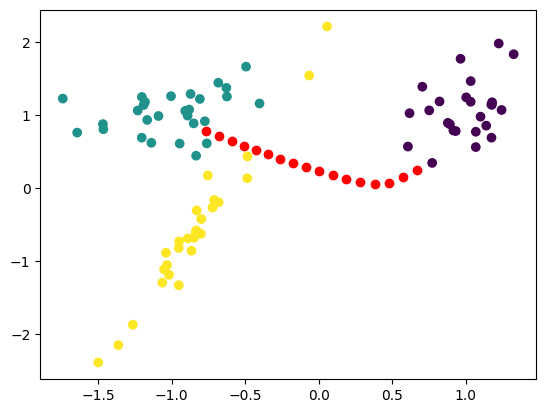

CURRENT PROBA: tensor(0.0163, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.9680, 0.4631]], requires_grad=True)
CURRENT PROBA: tensor(0.0227, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.8703, 0.3642]], requires_grad=True)
CURRENT PROBA: tensor(0.0314, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.7769, 0.2679]], requires_grad=True)
CURRENT PROBA: tensor(0.0428, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.6868, 0.1717]], requires_grad=True)
CURRENT PROBA: tensor(0.0561, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.5999, 0.0742]], requires_grad=True)
CURRENT PROBA: tensor(0.0703, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[ 0.5146, -0.0150]], requires_grad=True)
CURRENT PROBA: tensor(0.0830, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[ 0.4292, -0.0680]], requires_grad=True)
CURRENT PROBA: tensor(0.0934, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[ 0.3426, -0.0707]], requires_grad=True)
CURRENT PROBA: tensor(0.1056, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[ 0.2549, -0.050

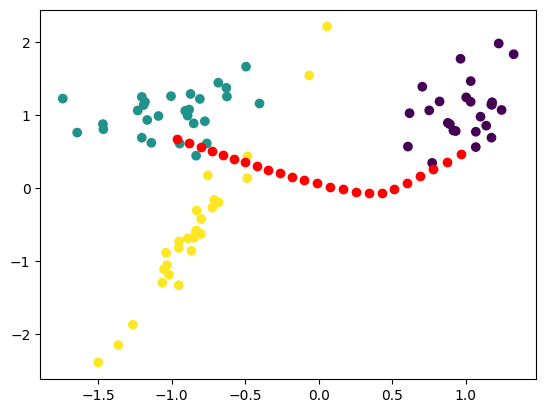

CURRENT PROBA: tensor(0.0617, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.5066, 0.4700]], requires_grad=True)
CURRENT PROBA: tensor(0.0901, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.4087, 0.3880]], requires_grad=True)
CURRENT PROBA: tensor(0.1214, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.3119, 0.4051]], requires_grad=True)
CURRENT PROBA: tensor(0.1602, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.2168, 0.4525]], requires_grad=True)
CURRENT PROBA: tensor(0.2109, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.1243, 0.5102]], requires_grad=True)
CURRENT PROBA: tensor(0.2751, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[0.0347, 0.5709]], requires_grad=True)
CURRENT PROBA: tensor(0.3500, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[-0.0538,  0.6344]], requires_grad=True)
CURRENT PROBA: tensor(0.4324, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[-0.1412,  0.6993]], requires_grad=True)
CURRENT PROBA: tensor(0.5219, grad_fn=<SelectBackward0>)
NEW CF:  tensor([[-0.2282,  0.7659]

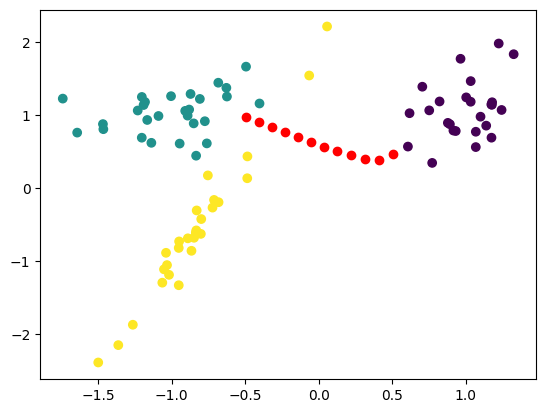

In [260]:

delta = 0.5
final_cf = []
for point in knn_point(X_train,point_of_interest,3):
    cf = deepcopy(point).reshape(1,-1)

    counter_factual_steps = []

    counter_factual = torch.tensor(cf, requires_grad=True)

    current_proba,_ = ensemble_model._predict(counter_factual)
    m,v,t = 0,0,1
    while current_proba[0,TARGET_CLASS] < 0.8:
            print("CURRENT PROBA:", current_proba[0,TARGET_CLASS])
            current_proba = (-current_proba)

            # Compute the gradient for the counterfactual
            (current_proba[0,TARGET_CLASS]).backward()

            # normalize counter factual
            counter_factual, (m,v,t) = adam_step(counter_factual, counter_factual.grad,lr=0.1,m=m,v=v,t=t)

            # Put counter_factual back to normal
            print("NEW CF: ", counter_factual)

            counter_factual_steps.append(counter_factual.clone().detach())

            current_proba,_ = ensemble_model._predict(counter_factual)

    counter_factual_steps = [cf.detach().numpy() for cf in counter_factual_steps]
    counter_factual_steps = np.concatenate(counter_factual_steps,axis=0)

    plt.scatter(X_train[:,0],X_train[:,1],c=y_train)
    plt.scatter(counter_factual_steps[:,0],counter_factual_steps[:,1],c="red")
    plt.show()

    final_cf.append(counter_factual.detach().clone())


CURRENT PROBA: tensor(0.0413, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1376, 0.0377]])
CF: tensor([[0.6715, 0.2457]], requires_grad=True)
CURRENT PROBA: tensor(0.0571, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1872, 0.0301]])
CF: tensor([[0.5734, 0.1458]], requires_grad=True)
CURRENT PROBA: tensor(0.0750, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.2116, 0.0088]])
CF: tensor([[0.4762, 0.0528]], requires_grad=True)
CURRENT PROBA: tensor(0.0919, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.2109, -0.0275]])
CF: tensor([[0.3789, 0.0082]], requires_grad=True)
CURRENT PROBA: tensor(0.1073, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.1858, -0.0862]])
CF: tensor([[0.2810, 0.0235]], requires_grad=True)
CURRENT PROBA: tensor(0.1268, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.1947, -0.1393]])
CF: tensor([[0.1828, 0.0616]], requires_grad=True)
CURRENT PROBA: tensor(0.1522, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.2036, -0.2063]])
CF: tensor([[0.0847, 0.1096]

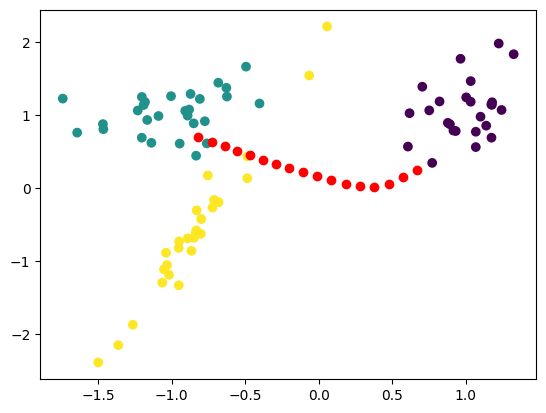

CURRENT PROBA: tensor(0.0163, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0485, 0.0215]])
CF: tensor([[0.9680, 0.4631]], requires_grad=True)
CURRENT PROBA: tensor(0.0227, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0680, 0.0265]])
CF: tensor([[0.8702, 0.3641]], requires_grad=True)
CURRENT PROBA: tensor(0.0314, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0998, 0.0357]])
CF: tensor([[0.7764, 0.2680]], requires_grad=True)
CURRENT PROBA: tensor(0.0428, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1322, 0.0379]])
CF: tensor([[0.6859, 0.1725]], requires_grad=True)
CURRENT PROBA: tensor(0.0562, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1671, 0.0310]])
CF: tensor([[0.5981, 0.0760]], requires_grad=True)
CURRENT PROBA: tensor(0.0706, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1886, 0.0069]])
CF: tensor([[ 0.5117, -0.0181]], requires_grad=True)
CURRENT PROBA: tensor(0.0834, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.1777, -0.0243]])
CF: tensor([[ 0.4247, -0.0881]],

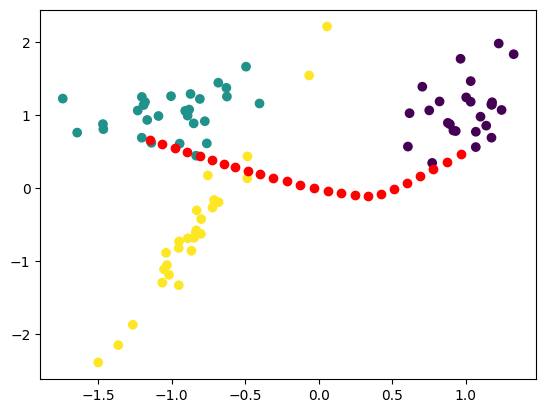

CURRENT PROBA: tensor(0.0617, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.2521, 0.0329]])
CF: tensor([[0.5066, 0.4700]], requires_grad=True)
CURRENT PROBA: tensor(0.0901, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.3411, 0.0117]])
CF: tensor([[0.4085, 0.3778]], requires_grad=True)
CURRENT PROBA: tensor(0.1210, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.3761, -0.0377]])
CF: tensor([[0.3110, 0.3701]], requires_grad=True)
CURRENT PROBA: tensor(0.1578, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.4351, -0.0801]])
CF: tensor([[0.2146, 0.4068]], requires_grad=True)
CURRENT PROBA: tensor(0.2055, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.5097, -0.1483]])
CF: tensor([[0.1201, 0.4589]], requires_grad=True)
CURRENT PROBA: tensor(0.2668, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.5882, -0.2270]])
CF: tensor([[0.0274, 0.5169]], requires_grad=True)
CURRENT PROBA: tensor(0.3398, grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.6289, -0.2931]])
CF: tensor([[-0.0640,  0.5

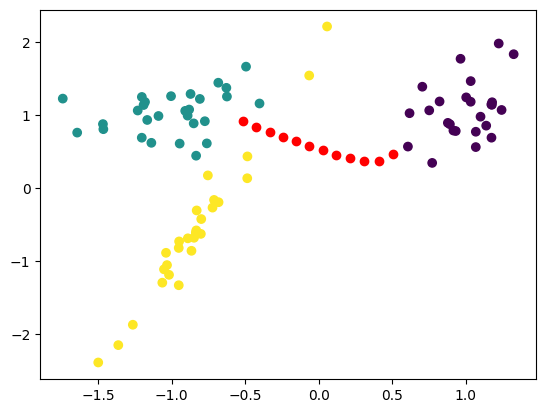

In [261]:
def predict_proba(X):
    y_pred_proba,_ = ensemble_model._predict(X)
    return y_pred_proba

def difference_au(model,point,k=3):
    """
    :param model:
    :param point:
    :param k:
    :return:
    """
    # Get the nearest neighbours
    nearest_neighbours = knn_point(X_train,point.detach().numpy(),k)
    # Get the gradients of the nearest neighbours
    nearest_neighbours = torch.tensor(nearest_neighbours, requires_grad=True)
    probs_nn,_ = model.predict(nearest_neighbours)
    probs_point, _ = model.predict(point)
    au_nn = get_AU(nearest_neighbours)
    au_point = get_AU(point)
    difference = (au_point - au_nn).sum()
    return difference

cf = deepcopy(point_of_interest).reshape(1,-1)
counter_factual = torch.tensor(cf, requires_grad=True)
tensor_point = torch.tensor(point_of_interest, requires_grad=True)


trade_off =  1e-2

for point in knn_point(X_train,point_of_interest,3):
    cf = deepcopy(point).reshape(1,-1)
    counter_factual = torch.tensor(cf, requires_grad=True)
    counter_factual_steps = []

    with torch.enable_grad():
        current_proba,_ = ensemble_model._predict(counter_factual)
        m,v,t = 0,0,1
        while current_proba[0,TARGET_CLASS] < 0.8:
            print("CURRENT PROBA:", current_proba[0,TARGET_CLASS])
            current_proba = -(current_proba)
            (current_proba[0,TARGET_CLASS] - trade_off*difference_au(ensemble_model,counter_factual,k=3)).backward()
            print("GRADIENT:", counter_factual.grad)
            counter_factual, (m,v,t) = adam_step(counter_factual, counter_factual.grad,lr=0.1,m=m,v=v,t=t)

            #counter_factual = (counter_factual + 0.1*counter_factual.grad).clone().detach().requires_grad_(True)
            with torch.no_grad():
                counter_factual_steps.append(counter_factual.clone())
            print("CF:", counter_factual)
            current_proba,_ = ensemble_model._predict(counter_factual)

    counter_factual_steps = [cf.detach().numpy() for cf in counter_factual_steps]
    counter_factual_steps = np.concatenate(counter_factual_steps,axis=0)


    plt.scatter(X_train[:,0],X_train[:,1],c=y_train)
    plt.scatter(counter_factual_steps[:,0],counter_factual_steps[:,1],c="red")
    plt.show()

# Robustness/ Plausability
- Robustness: Model shifts should not occur.
- Plausability: The CF is from the data manifold.
Shouldnt both be just the epistemic uncertainty???

## Plausability

We want the point to places in a place where it is realisitic to achieve.
(But now this would be more the 3rd property of the evidential model.)
Thus it must come from the data manifold and inherently have low epistemic uncertainty.


EU: tensor([0.0088], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0742, 0.0399]])
CF: tensor([[0.8039, 0.2541]], requires_grad=True)
EU: tensor([0.0107], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1087, 0.0443]])
CF: tensor([[0.7066, 0.1545]], requires_grad=True)
EU: tensor([0.0141], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1474, 0.0427]])
CF: tensor([[0.6121, 0.0548]], requires_grad=True)
EU: tensor([0.0192], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1839, 0.0302]])
CF: tensor([[ 0.5200, -0.0452]], requires_grad=True)
EU: tensor([0.0258], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1841, 0.0079]])
CF: tensor([[ 0.4278, -0.1412]], requires_grad=True)
EU: tensor([0.0296], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.1257, -0.0539]])
CF: tensor([[ 0.3341, -0.1881]], requires_grad=True)
EU: tensor([0.0313], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.0995, -0.0798]])
CF: tensor([[ 0.2389, -0.1970]], requires_grad=True)
EU: tensor([0.0316], grad_fn=<Select

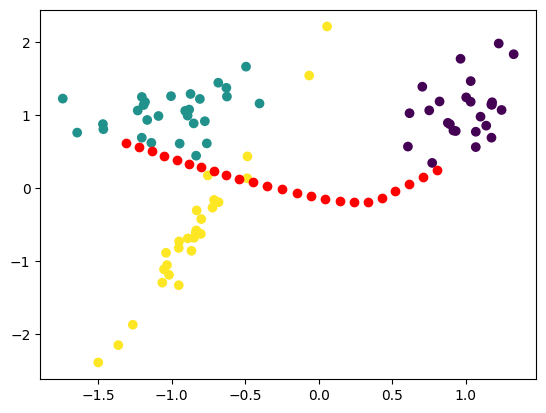

In [262]:
def get_EU(X):
    TU,AU,EU = get_uncertainty_decomposition(ensemble_model,X,with_grad=True)
    return EU
cf = deepcopy(point_of_interest).reshape(1,-1)
counter_factual = torch.tensor(cf, requires_grad=True)
tensor_point = torch.tensor(point_of_interest, requires_grad=True)


counter_factual_steps = []
with torch.enable_grad():
    current_proba,_ = ensemble_model._predict(counter_factual)
    m,v,t = 0,0,1
    while current_proba[0,TARGET_CLASS] < 0.8:
        current_proba = -current_proba
        print("EU:", get_EU(counter_factual))
        (current_proba[0,TARGET_CLASS] - get_EU(counter_factual)).backward()
        print("GRADIENT:", counter_factual.grad)
        counter_factual, (m,v,t) = adam_step(counter_factual, counter_factual.grad,lr=0.1,m=m,v=v,t=t)

        #counter_factual = (counter_factual + 0.1*counter_factual.grad).clone().detach().requires_grad_(True)
        with torch.no_grad():
            counter_factual_steps.append(counter_factual.clone())
        print("CF:", counter_factual)
        current_proba,_ = ensemble_model._predict(counter_factual)

counter_factual_steps = [cf.detach().numpy() for cf in counter_factual_steps]
counter_factual_steps = np.concatenate(counter_factual_steps,axis=0)


plt.scatter(X_train[:,0],X_train[:,1],c=y_train)
plt.scatter(counter_factual_steps[:,0],counter_factual_steps[:,1],c="red")
plt.show()

# Discriminativeness

We want the CF to be clearly distiniguishable from points not having the target class.

## KL Divergence
We try to maximize the KL Divergence between different points of target class and cf.

In [263]:
def kl_divergence_different_from_target(model, point, target_class, k=3):
    """
    :param model:
    :param point:
    :param k:
    :return:
    """
    # Get the nearest neighbours
    nearest_neighbours = knn_point(X_train[y_train != target_class],point.detach().numpy(),k)

    # Get the gradients of the nearest neighbours
    nearest_neighbours = torch.tensor(nearest_neighbours, requires_grad=True)
    probs_nn,_ = model.predict(nearest_neighbours)
    probs_point, _ = model.predict(point)
    kl_diverg = -probs_nn.div(probs_point).log().mul(probs_nn).sum()
    return kl_diverg

kl_divergence_different_from_target(ensemble_model, tensor_point, TARGET_CLASS, 3)

tensor(-0.0480, grad_fn=<NegBackward0>)

CURRENT PROBA: tensor(0.0291, grad_fn=<SelectBackward0>)
tensor(0.0480, grad_fn=<NegBackward0>)
GRADIENT: tensor([[0.0741, 0.0258]])
CF: tensor([[0.8039, 0.2541]], requires_grad=True)
CURRENT PROBA: tensor(0.0403, grad_fn=<SelectBackward0>)
tensor(0.0460, grad_fn=<NegBackward0>)
GRADIENT: tensor([[0.0998, 0.0240]])
CF: tensor([[0.7058, 0.1540]], requires_grad=True)
CURRENT PROBA: tensor(0.0539, grad_fn=<SelectBackward0>)
tensor(0.1235, grad_fn=<NegBackward0>)
GRADIENT: tensor([[0.1239, 0.0110]])
CF: tensor([[0.6094, 0.0569]], requires_grad=True)
CURRENT PROBA: tensor(0.0688, grad_fn=<SelectBackward0>)
tensor(0.3124, grad_fn=<NegBackward0>)
GRADIENT: tensor([[ 0.1404, -0.0132]])
CF: tensor([[ 0.5142, -0.0059]], requires_grad=True)
CURRENT PROBA: tensor(0.0833, grad_fn=<SelectBackward0>)
tensor(0.5996, grad_fn=<NegBackward0>)
GRADIENT: tensor([[ 0.1391, -0.0417]])
CF: tensor([[ 0.4191, -0.0103]], requires_grad=True)
CURRENT PROBA: tensor(0.0990, grad_fn=<SelectBackward0>)
tensor(0.9016, 

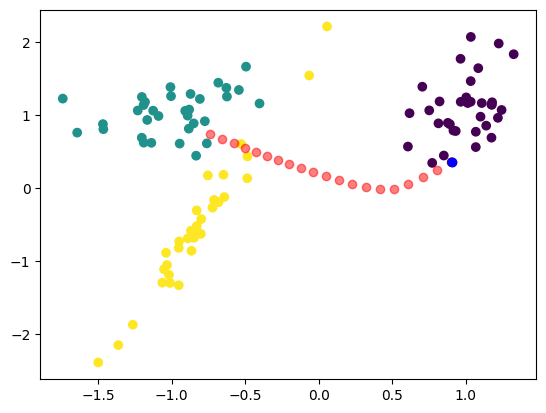

In [264]:
def predict_proba(X):
    y_pred_proba, _ = ensemble_model._predict(X)
    return y_pred_proba


cf = deepcopy(point_of_interest).reshape(1, -1)
counter_factual = torch.tensor(cf, requires_grad=True)
tensor_point = torch.tensor(point_of_interest, requires_grad=True)

counter_factual_steps = [counter_factual]
trade_off = 1e-2

with torch.enable_grad():
    current_proba, _ = ensemble_model._predict(counter_factual)
    m, v, t = 0, 0, 1
    while current_proba[0, TARGET_CLASS] < 0.8:
        print("CURRENT PROBA:", current_proba[0, TARGET_CLASS])
        current_proba = -(current_proba)
        print(-kl_divergence_different_from_target(ensemble_model, counter_factual,TARGET_CLASS, 3))
        (current_proba[0, TARGET_CLASS] - trade_off* kl_divergence_different_from_target(ensemble_model, counter_factual, TARGET_CLASS, k=3)).backward()
        print("GRADIENT:", counter_factual.grad)
        counter_factual, (m, v, t) = adam_step(counter_factual, counter_factual.grad, lr=0.1, m=m, v=v, t=t)

        #counter_factual = (counter_factual + 0.1*counter_factual.grad).clone().detach().requires_grad_(True)
        with torch.no_grad():
            counter_factual_steps.append(counter_factual.clone())
        print("CF:", counter_factual)
        current_proba, _ = ensemble_model._predict(counter_factual)

counter_factual_steps = [cf.detach().numpy() for cf in counter_factual_steps]
counter_factual_steps = np.concatenate(counter_factual_steps, axis=0)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.scatter(counter_factual_steps[:, 0], counter_factual_steps[:, 1], c="red",alpha=0.5)
plt.scatter(counter_factual_steps[0, 0], counter_factual_steps[0, 1], c="blue")
plt.show()

## We minimize the AU regarding the CF

CURRENT PROBA: tensor(0.0291, grad_fn=<SelectBackward0>)
AU:  tensor([0.3351], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0780, 0.0278]])
CF: tensor([[0.8039, 0.2541]], requires_grad=True)
CURRENT PROBA: tensor(0.0403, grad_fn=<SelectBackward0>)
AU:  tensor([0.4380], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1094, 0.0292]])
CF: tensor([[0.7061, 0.1543]], requires_grad=True)
CURRENT PROBA: tensor(0.0538, grad_fn=<SelectBackward0>)
AU:  tensor([0.5605], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1408, 0.0199]])
CF: tensor([[0.6106, 0.0545]], requires_grad=True)
CURRENT PROBA: tensor(0.0686, grad_fn=<SelectBackward0>)
AU:  tensor([0.6806], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.1661, -0.0011]])
CF: tensor([[ 0.5166, -0.0329]], requires_grad=True)
CURRENT PROBA: tensor(0.0821, grad_fn=<SelectBackward0>)
AU:  tensor([0.7728], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.1612, -0.0287]])
CF: tensor([[ 0.4226, -0.0728]], requires_grad=True)
CURRENT PROBA: tensor(

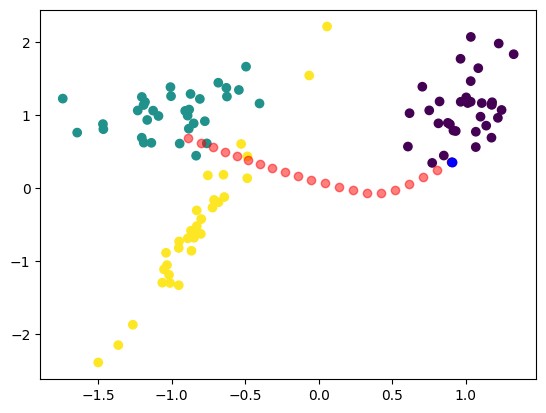

In [265]:
def predict_proba(X):
    y_pred_proba, _ = ensemble_model._predict(X)
    return y_pred_proba


cf = deepcopy(point_of_interest).reshape(1, -1)
counter_factual = torch.tensor(cf, requires_grad=True)
tensor_point = torch.tensor(point_of_interest, requires_grad=True)

counter_factual_steps = [counter_factual]
optim = torch.optim.Adam([counter_factual], lr=0.1)

trade_off = 1e-2

with torch.enable_grad():
    current_proba, _ = ensemble_model._predict(counter_factual)
    m, v, t = 0, 0, 1
    while current_proba[0, TARGET_CLASS] < 0.8:
        print("CURRENT PROBA:", current_proba[0, TARGET_CLASS])
        current_proba = -(current_proba)
        print("AU: ", get_AU(counter_factual))
        # one can even think about combining them: - trade_off*kl_divergence_different_from_target(ensemble_model,counter_factual,TARGET_CLASS,3)
        (current_proba[0, TARGET_CLASS] - trade_off*get_AU(counter_factual)).backward()
        print("GRADIENT:", counter_factual.grad)
        counter_factual, (m, v, t) = adam_step(counter_factual, counter_factual.grad, lr=0.1, m=m, v=v, t=t)

        #counter_factual = (counter_factual + 0.1*counter_factual.grad).clone().detach().requires_grad_(True)
        with torch.no_grad():
            counter_factual_steps.append(counter_factual.clone())
        print("CF:", counter_factual)
        current_proba, _ = ensemble_model._predict(counter_factual)

counter_factual_steps = [cf.detach().numpy() for cf in counter_factual_steps]
counter_factual_steps = np.concatenate(counter_factual_steps, axis=0)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.scatter(counter_factual_steps[:, 0], counter_factual_steps[:, 1], c="red",alpha=0.5)
plt.scatter(counter_factual_steps[0, 0], counter_factual_steps[0, 1], c="blue")
plt.show()

## Combinning both

CURRENT PROBA: tensor(0.0291, grad_fn=<SelectBackward0>)
AU:  tensor([0.3351], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.0799, 0.0287]])
CF: tensor([[0.8039, 0.2541]], requires_grad=True)
CURRENT PROBA: tensor(0.0403, grad_fn=<SelectBackward0>)
AU:  tensor([0.4380], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1075, 0.0280]])
CF: tensor([[0.7058, 0.1541]], requires_grad=True)
CURRENT PROBA: tensor(0.0539, grad_fn=<SelectBackward0>)
AU:  tensor([0.5610], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[0.1318, 0.0160]])
CF: tensor([[0.6092, 0.0552]], requires_grad=True)
CURRENT PROBA: tensor(0.0688, grad_fn=<SelectBackward0>)
AU:  tensor([0.6815], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.1487, -0.0103]])
CF: tensor([[ 0.5139, -0.0177]], requires_grad=True)
CURRENT PROBA: tensor(0.0830, grad_fn=<SelectBackward0>)
AU:  tensor([0.7721], grad_fn=<SelectBackward0>)
GRADIENT: tensor([[ 0.1415, -0.0426]])
CF: tensor([[ 0.4183, -0.0317]], requires_grad=True)
CURRENT PROBA: tensor(

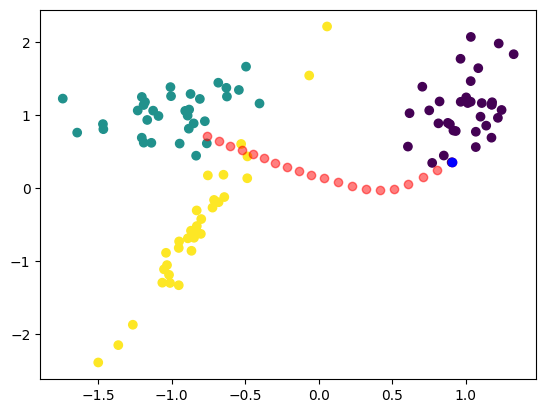

In [266]:
def predict_proba(X):
    y_pred_proba, _ = ensemble_model._predict(X)
    return y_pred_proba


cf = deepcopy(point_of_interest).reshape(1, -1)
counter_factual = torch.tensor(cf, requires_grad=True)
tensor_point = torch.tensor(point_of_interest, requires_grad=True)

counter_factual_steps = [counter_factual]
optim = torch.optim.Adam([counter_factual], lr=0.1)

trade_off = 1e-2

with torch.enable_grad():
    current_proba, _ = ensemble_model._predict(counter_factual)
    m, v, t = 0, 0, 1
    while current_proba[0, TARGET_CLASS] < 0.8:
        print("CURRENT PROBA:", current_proba[0, TARGET_CLASS])
        current_proba = -(current_proba)
        print("AU: ", get_AU(counter_factual))
        (current_proba[0, TARGET_CLASS] - trade_off*get_AU(counter_factual) - trade_off*kl_divergence_different_from_target(ensemble_model,counter_factual,TARGET_CLASS,3)).backward()
        print("GRADIENT:", counter_factual.grad)
        counter_factual, (m, v, t) = adam_step(counter_factual, counter_factual.grad, lr=0.1, m=m, v=v, t=t)

        #counter_factual = (counter_factual + 0.1*counter_factual.grad).clone().detach().requires_grad_(True)
        with torch.no_grad():
            counter_factual_steps.append(counter_factual.clone())
        print("CF:", counter_factual)
        current_proba, _ = ensemble_model._predict(counter_factual)

counter_factual_steps = [cf.detach().numpy() for cf in counter_factual_steps]
counter_factual_steps = np.concatenate(counter_factual_steps, axis=0)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.scatter(counter_factual_steps[:, 0], counter_factual_steps[:, 1], c="red",alpha=0.5)
plt.scatter(counter_factual_steps[0, 0], counter_factual_steps[0, 1], c="blue")
plt.show()